In [1]:
import sys
import os

import numpy as np
import pandas as pd
import scipy
from scipy.signal import butter, filtfilt, find_peaks
from scipy.spatial.transform import Rotation as Rot
from scipy.interpolate import interp1d
from scipy.linalg import expm

import matplotlib.pyplot as plt
%matplotlib inline

print("Python version: {}".format(sys.version))
print("numpy version: {}".format(np.__version__))
print("pandas version: {}".format(pd.__version__))
print("scipy version: {}".format(scipy.__version__))

Python version: 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]
numpy version: 2.2.6
pandas version: 2.2.3
scipy version: 1.15.1


# Import data

In [2]:
filepath = "../data/subject_2/"
df_acc = pd.read_csv(filepath+"imu_run_acc.csv", header=None)
df_acc.columns = ["x", "y", "z"]

df_gyr = pd.read_csv(filepath+"imu_run_gyr.csv", header=None)
df_gyr.columns = ["x", "y", "z"]
df_gyr = df_gyr

sf = 240  # Sampling Frequency


mocap_list = ["optical_run_pos_m1.csv", "optical_run_pos_m2.csv", "optical_run_pos_m3.csv", "optical_run_pos_m4.csv"]
dfs = []
for i, filename in enumerate(mocap_list):
    df = pd.read_csv(filepath + filename, header=None)
    df.columns = [f'm{i+1}_{col}' for col in ["x", "y", "z"]]
    dfs.append(df)
df_mocap_raw = pd.concat(dfs, axis=1)

sf_mocap = 100



In [3]:
# --- Upsampling (Linear Interpolation) ---
num_samples_orig = len(df_mocap_raw)
time_orig = np.linspace(0, (num_samples_orig - 1) / sf_mocap, num_samples_orig)
time_new = np.linspace(0, (num_samples_orig - 1) / sf_mocap, int(num_samples_orig * sf / sf_mocap))
f_interp = interp1d(time_orig, df_mocap_raw.values, axis=0, kind='linear', fill_value="extrapolate")
df_mocap_upsampled = pd.DataFrame(f_interp(time_new), columns=df_mocap_raw.columns)

# --- Filtering (Recursive 4th-order 20Hz Butterworth) ---
nyq = 0.5 * sf
cutoff = 20
order = 4
b, a = butter(order, cutoff / nyq, btype="low")
mocap_filt_values = filtfilt(b, a, df_mocap_upsampled.values, axis=0)
df_mocap = pd.DataFrame(mocap_filt_values, columns=df_mocap_upsampled.columns)

##### Check tha data

In [5]:
# Check the duration of IMU and OMCS data
print(len(df_acc)/sf)
print(len(df_mocap_raw)/sf_mocap)

147.12916666666666
64.67


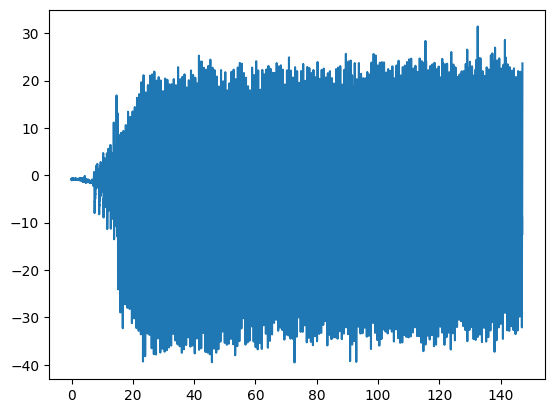

In [6]:
time = np.arange(len(df_acc)) / sf
plt.plot(time, df_acc["x"])

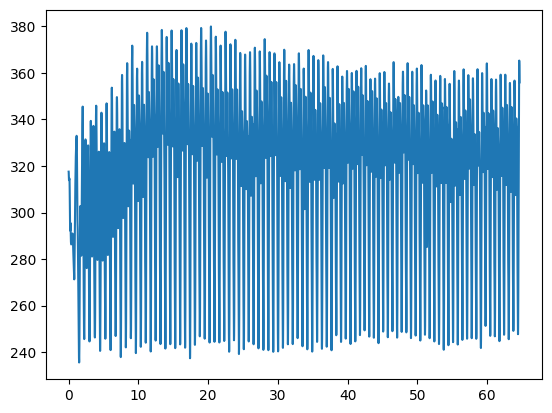

In [7]:
time = np.arange(len(df_mocap)) / sf
plt.plot(time, df_mocap["m1_z"])

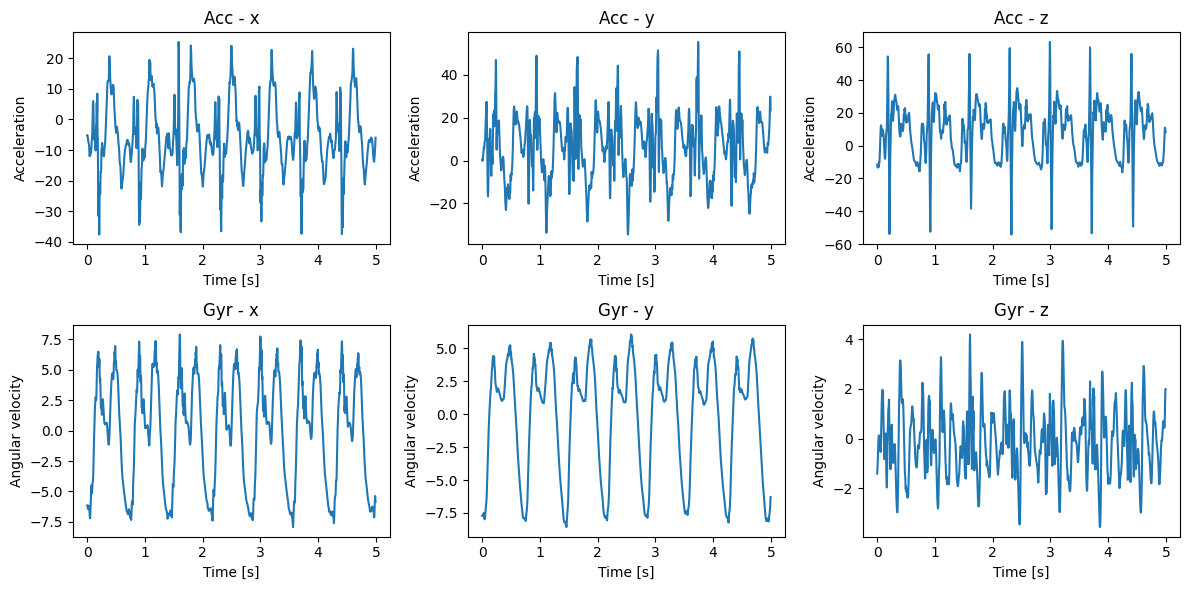

In [9]:
frame_plot = slice(40*sf, 45*sf)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

time = np.arange(len(df_acc[frame_plot])) / sf

for i, col in enumerate(['x', 'y', 'z']):
    axes[0, i].plot(time, df_acc[frame_plot][col])
    axes[0, i].set_title(f'Acc - {col}')
    axes[0, i].set_xlabel('Time [s]')
    axes[0, i].set_ylabel('Acceleration')

for i, col in enumerate(['x', 'y', 'z']):
    axes[1, i].plot(time, df_gyr[frame_plot][col])
    axes[1, i].set_title(f'Gyr - {col}')
    axes[1, i].set_xlabel('Time [s]')
    axes[1, i].set_ylabel('Angular velocity')

plt.tight_layout()
plt.show()

### Extract data of approximately constant cycle average velocity

In [8]:
frame_30sec = slice(30*sf, 60*sf)

df_acc_30s = df_acc[frame_30sec]
df_acc_30s.reset_index(drop=True, inplace=True)
df_gyr_30s = df_gyr[frame_30sec]
df_gyr_30s.reset_index(drop=True, inplace=True)

df_mocap_30s = df_mocap[frame_30sec]
df_mocap_30s.reset_index(drop=True, inplace=True)

# IMU data

## Step 0: Segment into gait cycles

In [17]:
peaks, _ = find_peaks(-df_gyr_30s['y'], distance=sf*0.5, height=4)

cycle_intervals = []

for peak in peaks[:-1]:
    # Find first Zero-crossing point for each peak = start of the gait cycle
    idx = peak
    while idx > 0:
        if df_gyr_30s['y'][idx] < 0 and df_gyr_30s['y'][idx+1] >= 0:
            start_idx = idx
            break
        idx += 1
    else:
        continue
    cycle_intervals.append(start_idx)

# Get start and end index for each cycle
cycle_steps = []
for i in range(len(cycle_intervals) - 1):
    start = cycle_intervals[i]
    end = cycle_intervals[i+1]
    cycle_steps.append((start, end))

cycle_steps = np.array(cycle_steps)

print(f"The number of extracted gait cycles: {len(cycle_steps)}")
print(f"First 5 index:\n{cycle_steps[:5]}")

The number of extracted gait cycles: 42
First 5 index:
[[ 74 243]
 [243 413]
 [413 580]
 [580 748]
 [748 918]]


[74, 243, 413, 580, 748, 918, 1083, 1251, 1421, 1588, 1757, 1925, 2094, 2261]


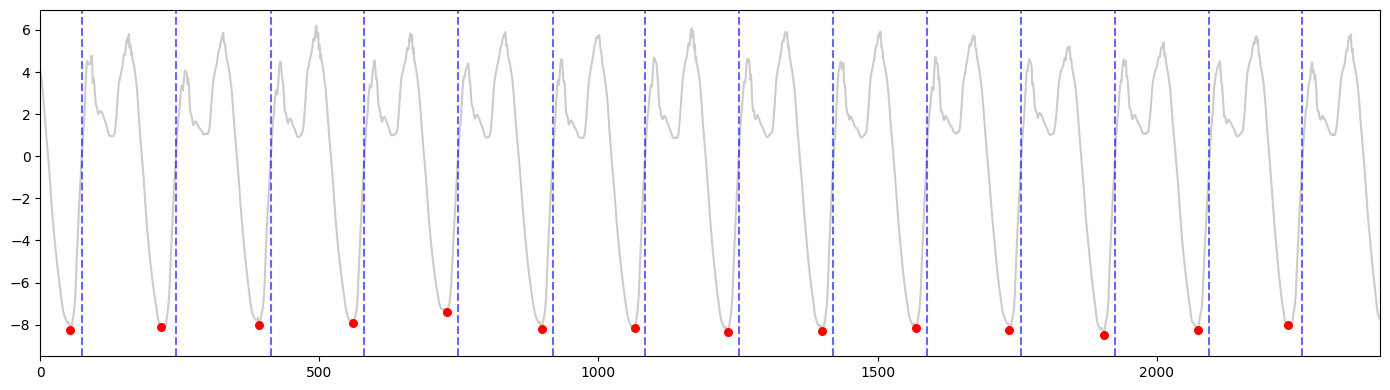

[2429, 2599, 2767, 2937, 3105, 3272, 3442, 3609, 3777, 3945, 4110, 4280, 4447, 4613, 4779]


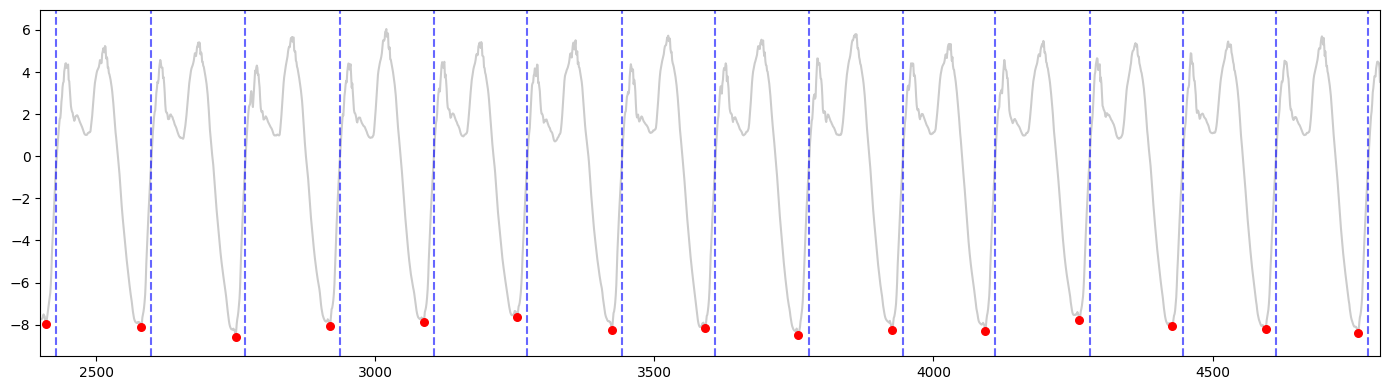

[4945, 5108, 5272, 5434, 5598, 5761, 5924, 6084, 6243, 6402, 6563, 6723, 6882]


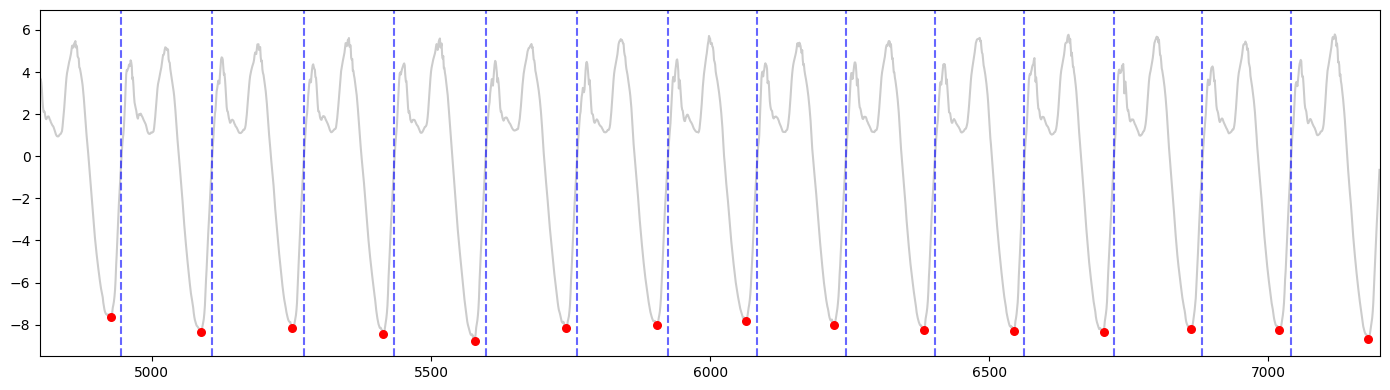

In [36]:
idx_plot = []
for start, _ in cycle_steps:
    idx_plot.append(int(start))

for plot_sec in [0, 10, 20]:
    print([val for val in idx_plot if (plot_sec*sf) <= val <= ((plot_sec+10)*sf)])
    plt.figure(figsize=(14, 4))

    # Angular velocity
    plt.plot(df_gyr_30s['y'], color='gray', alpha=0.4)
    # Detected peaks
    plt.scatter(peaks, df_gyr_30s['y'][peaks], 
                color='red', s=30, label='Detected Peak (IC)', zorder=3)
    # Zero-crossing point
    for start, end in cycle_steps:
        plt.axvline(start, color='blue', linestyle='--', alpha=0.6)
        if end == cycle_steps[-1][1]:
            plt.axvline(end, color='blue', linestyle='--', alpha=0.6)

    plt.xlim(plot_sec*sf, (plot_sec+10)*sf) 
    plt.tight_layout()
    plt.show()

In [37]:
# Extract full-gait cycle data
start, end = cycle_steps[0][0], cycle_steps[-1][1]
gyr_30sec = df_gyr_30s.iloc[start:end].values
acc_30sec = df_acc_30s.iloc[start:end].values

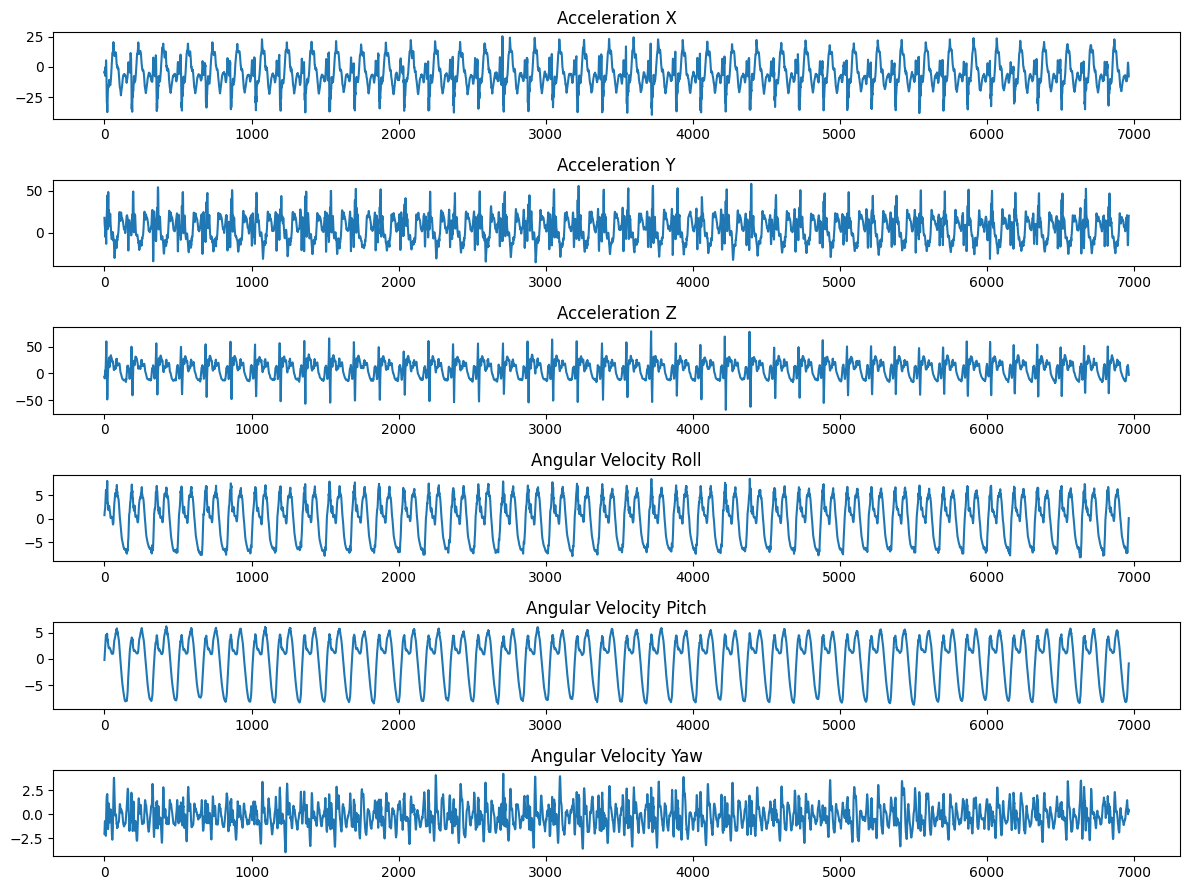

In [39]:
plt.figure(figsize=(12, 9))

plt.subplot(6, 1, 1)
plt.plot(acc_30sec[:, 0])
plt.title("Acceleration X")

plt.subplot(6, 1, 2)
plt.plot(acc_30sec[:, 1])
plt.title("Acceleration Y")

plt.subplot(6, 1, 3)
plt.plot(acc_30sec[:, 2])
plt.title("Acceleration Z")

plt.subplot(6, 1, 4)
plt.plot(gyr_30sec[:, 0])
plt.title("Angular Velocity Roll")

plt.subplot(6, 1, 5)
plt.plot(gyr_30sec[:, 1])
plt.title("Angular Velocity Pitch")

plt.subplot(6, 1, 6)
plt.plot(gyr_30sec[:, 2])
plt.title("Angular Velocity Yaw")

plt.tight_layout()
plt.show()

## Step 1: From Sensor CS to Partly Functional CS

In [40]:
from sklearn.decomposition import PCA

# Get the first PCA
pca = PCA(n_components=1)
pca.fit(gyr_30sec)
y_pf_s = pca.components_[0]
y_pf_s /= np.linalg.norm(y_pf_s)

x_temp = np.array([1.0, 0.0, 0.0])  # Temporary X-axis
# TRIAD algorithm
z_pf_s = np.cross(x_temp, y_pf_s)
z_pf_s /= np.linalg.norm(z_pf_s)

x_pf_s = np.cross(y_pf_s, z_pf_s)
x_pf_s /= np.linalg.norm(x_pf_s)


# Get the time-invariant orthonormal rotation matrix from CS_pf to CS_S
R_pf_s = np.stack([x_pf_s, y_pf_s, z_pf_s], axis=1)
R_s_pf = R_pf_s.T

# Rotate the acc and gyr data
acc_pf = (R_s_pf @ acc_30sec.T).T
gyr_pf = (R_s_pf @ gyr_30sec.T).T

In [53]:
R_s_pf.shape

(3, 3)

In [60]:
x_pf_s

array([ 0.7052525 , -0.70888097, -0.01032882])

In [62]:
y_pf_s

array([0.70895621, 0.70517765, 0.01027487])

In [65]:
z_pf_s

array([ 0.        , -0.01456906,  0.99989387])

In [63]:
R_s_pf

array([[ 0.7052525 , -0.70888097, -0.01032882],
       [ 0.70895621,  0.70517765,  0.01027487],
       [ 0.        , -0.01456906,  0.99989387]])

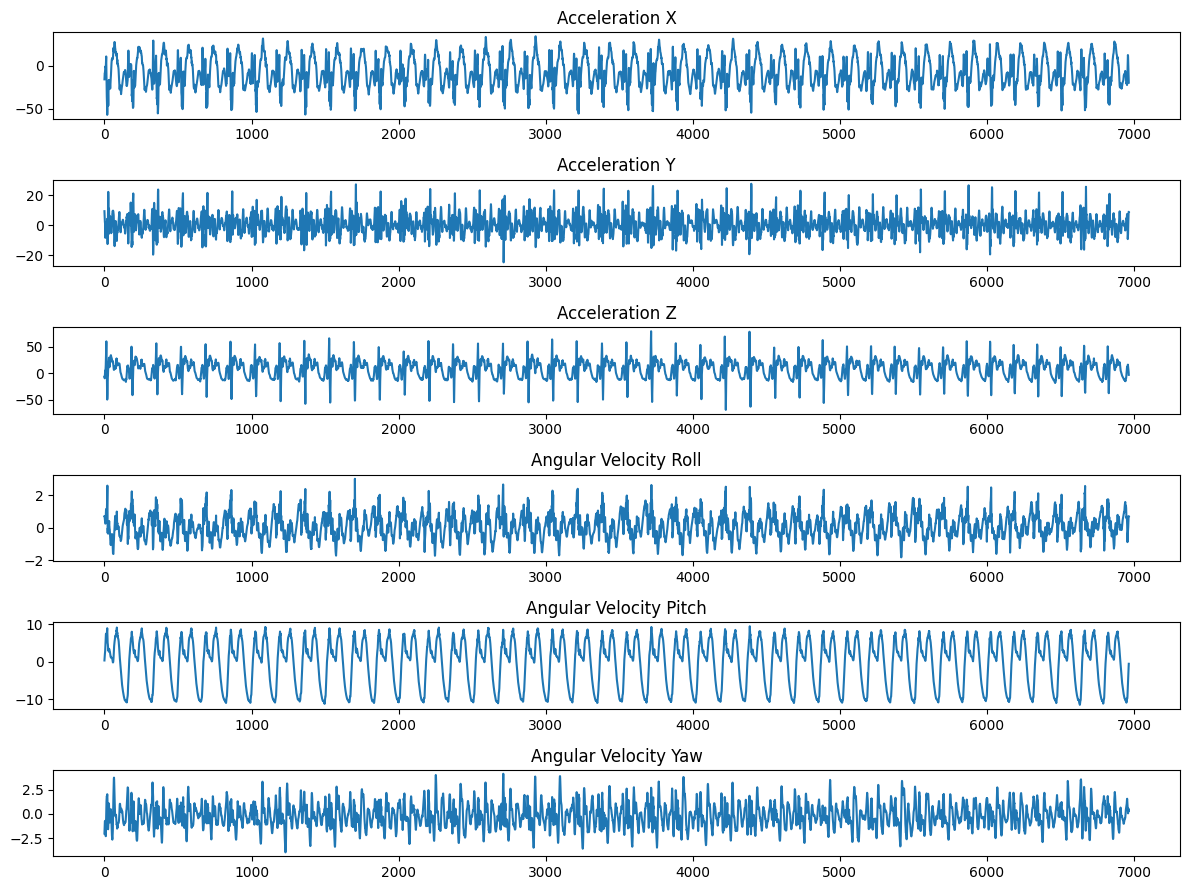

In [126]:
plt.figure(figsize=(12, 9))

plt.subplot(6, 1, 1)
plt.plot(acc_pf[:, 0])
# plt.legend(['X (Forward)'])
plt.title("Acceleration X")

plt.subplot(6, 1, 2)
plt.plot(acc_pf[:, 1])
# plt.legend(['Y (Lateral)'])
plt.title("Acceleration Y")

plt.subplot(6, 1, 3)
plt.plot(acc_pf[:, 2])
# plt.legend(['Z (Vertical)'])
plt.title("Acceleration Z")

plt.subplot(6, 1, 4)
plt.plot(gyr_pf[:, 0])
# plt.legend(['Roll'])
plt.title("Angular Velocity Roll")

plt.subplot(6, 1, 5)
plt.plot(gyr_pf[:, 1])
# plt.legend(['Pitch (Main)'])
plt.title("Angular Velocity Pitch")

plt.subplot(6, 1, 6)
plt.plot(gyr_pf[:, 2])
# plt.legend(['Yaw'])
plt.title("Angular Velocity Yaw")

plt.tight_layout()
plt.savefig("../picture/acc-gyr_pf.png")
plt.show()

In [43]:
# --- Check the explained variance of each PCA component ---
pca_check = PCA(n_components=3)
pca_check.fit(gyr_30sec)

exp_var_ratio = pca_check.explained_variance_ratio_

print("--- PCA Explained Variance Ratio ---")
print(f"PC1 (ML-axis): {exp_var_ratio[0]:.2%}")
print(f"PC2:           {exp_var_ratio[1]:.2%}")
print(f"PC3:           {exp_var_ratio[2]:.2%}")
print(f"Total:         {sum(exp_var_ratio):.2%}")

--- PCA Explained Variance Ratio ---
PC1 (ML-axis): 94.77%
PC2:           3.86%
PC3:           1.37%
Total:         100.00%


## Step 2: From Partly Functional CS to Drifting Partly Functional CS

In [44]:
dt = 1/sf

num_samples = gyr_pf.shape[0]
R_pf_df = np.zeros((num_samples, 3, 3))
R_pf_df[0] = np.eye(3)

for i in range(1, num_samples):
    w_x, w_y, w_z = gyr_pf[i-1]
    # Create skew-symmetric matrix
    omega_skew = np.array([
                            [0, -w_z, w_y],
                            [w_z, 0, -w_x],
                            [-w_y, w_x, 0]
                          ]
                         )
    
    # Update rotation matrix using exponential map (numerical solution of Bortz's differential equation)
    R_pf_df[i] = R_pf_df[i-1] @ expm(omega_skew * dt)

# np.einsum('nij,nj->ni', A, B) multiplies each vector B[i] by matrix A[i] at each time step i
acc_df = np.einsum('nij,nj->ni', R_pf_df, acc_pf)
gyr_df = np.einsum('nij,nj->ni', R_pf_df, gyr_pf)

In [54]:
R_pf_df.shape

(6966, 3, 3)

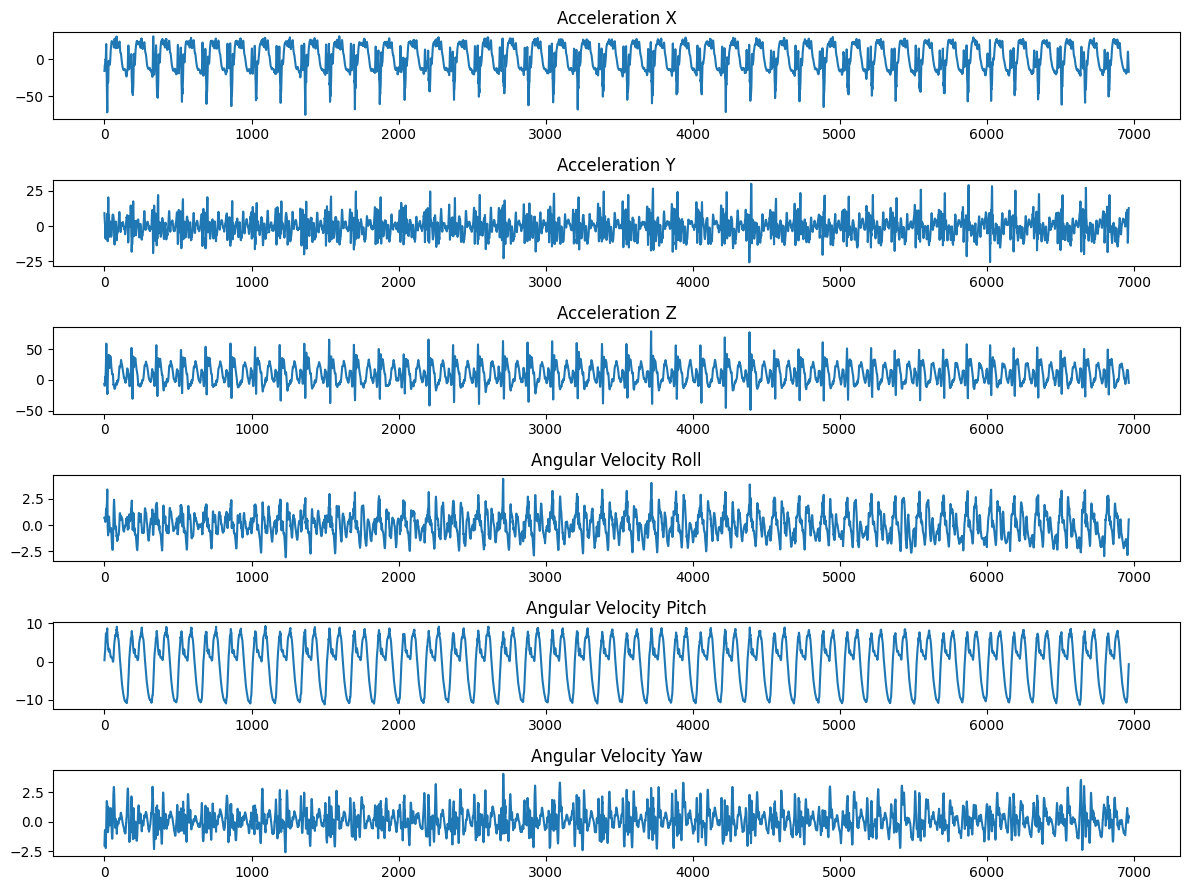

In [127]:
plt.figure(figsize=(12, 9))

plt.subplot(6, 1, 1)
plt.plot(acc_df[:, 0])
# plt.legend(['X (Forward)'])
plt.title("Acceleration X")

plt.subplot(6, 1, 2)
plt.plot(acc_df[:, 1])
# plt.legend(['Y (Lateral)'])
plt.title("Acceleration Y")

plt.subplot(6, 1, 3)
plt.plot(acc_df[:, 2])
# plt.legend(['Z (Vertical)'])
plt.title("Acceleration Z")

plt.subplot(6, 1, 4)
plt.plot(gyr_df[:, 0])
# plt.legend(['Roll'])
plt.title("Angular Velocity Roll")

plt.subplot(6, 1, 5)
plt.plot(gyr_df[:, 1])
# plt.legend(['Pitch (Main)'])
plt.title("Angular Velocity Pitch")

plt.subplot(6, 1, 6)
plt.plot(gyr_df[:, 2])
# plt.legend(['Yaw'])
plt.title("Angular Velocity Yaw")

plt.tight_layout()
plt.savefig("../picture/acc-gyr_df.png")
plt.show()

## Step 3: From Drifting Partly Functional CS to Drift-Free Functional CS

In [46]:
acc_f = np.zeros_like(acc_df)
acc_free = np.zeros_like(acc_df)
gyr_f = np.zeros_like(gyr_df)
R_df_f = np.zeros((len(cycle_steps), 3, 3))


for i in range(2, len(cycle_steps)-2, 1):
    # Extract 2 cycles before and after the current cycle (i)
    win_start_idx = int(cycle_steps[i-2][0])-int(cycle_steps[0][0])
    win_end_idx = int(cycle_steps[i+2][1])-int(cycle_steps[0][0])
    curr_start = int(cycle_steps[i][0]) - int(cycle_steps[0][0])
    curr_end = int(cycle_steps[i][1]) - int(cycle_steps[0][0])

    acc_df_5cycle = acc_df[win_start_idx:win_end_idx]
    gyr_df_5cycle = gyr_df[win_start_idx:win_end_idx]

    # Calculate the first principal component of angular velocity
    pca_5 = PCA(n_components=1)
    pca_5.fit(gyr_df_5cycle)
    y_df_f = pca_5.components_[0]
    y_df_f /= np.linalg.norm(y_df_f)
    
    # Use the 5-step average of acceleration (acc_df) within the window as the temporary Z axis
    z_temp = np.mean(acc_df_5cycle, axis=0)
    # print(np.linalg.norm(z_temp))

    # Construct orthogonal coordinate system using TRIAD algorithm
    x_df_f = np.cross(y_df_f, z_temp)
    x_df_f /= np.linalg.norm(x_df_f)

    z_df_f = np.cross(x_df_f, y_df_f)
    z_df_f /= np.linalg.norm(z_df_f)

    R_df_f_i = np.stack([x_df_f, y_df_f, z_df_f], axis=1)
    R_df_f[i] = R_df_f_i

    

In [47]:
# Correct potential 180-degree axis flips between consecutive cycles to ensure smooth orientation transitions across gait cycles

# Create candidate rotation matrices
R_rot_x = Rot.from_euler('x', 180, degrees=True).as_matrix()
R_rot_y = Rot.from_euler('y', 180, degrees=True).as_matrix()
R_rot_z = Rot.from_euler('z', 180, degrees=True).as_matrix()

R_df_f_fixed = [R_df_f[0]]

for i in range(1, len(R_df_f)):
    prev = R_df_f_fixed[-1]
    curr = R_df_f[i]

    # Which flip pattern is closest to the previous step?
    candidates = [curr, curr @ R_rot_x, curr @ R_rot_y, curr @ R_rot_z]
    # Select the one with minimum matrix difference (norm)
    best = min(candidates, key=lambda C: np.linalg.norm(C - prev))
    R_df_f_fixed.append(best)

R_df_f_fixed = np.array(R_df_f_fixed)

In [56]:
for i in range(2, len(cycle_steps)-2, 1):
    # Transform only the current cycle (i)
    acc_f[curr_start:curr_end] = (R_df_f_fixed[i] @ acc_df[curr_start:curr_end].T).T
    gyr_f[curr_start:curr_end] = (R_df_f_fixed[i] @ gyr_df[curr_start:curr_end].T).T
    
    # Remove gravity
    # Subtract the average gravity norm within the window from the vertical component (Z)
    acc_free[curr_start:curr_end] = acc_f[curr_start:curr_end].copy()
    acc_free[curr_start:curr_end, 2] -= np.linalg.norm(z_temp)

# --- Edge handling (Padding) ---
# Fill the first cycles (indices 0, 1) with the result from the 3rd cycle (i=2)
start_pad = int(cycle_steps[2][0]) - int(cycle_steps[0][0])
R_df_f[:2] = R_df_f_fixed[2]
acc_f[:start_pad] = (R_df_f_fixed[2] @ acc_df[:start_pad].T).T
gyr_f[:start_pad] = (R_df_f_fixed[2] @ gyr_df[:start_pad].T).T

# Fill the last 2 cycles with the result from the 3rd cycle from the end (num_cycles-3)
end_pad = int(cycle_steps[-3][1]) - int(cycle_steps[0][0])
R_df_f[-2:] = R_df_f_fixed[-3]
acc_f[end_pad:] = (R_df_f_fixed[-2] @ acc_df[end_pad:].T).T
gyr_f[end_pad:] = (R_df_f_fixed[-2] @ gyr_df[end_pad:].T).T

In [52]:
R_df_f_fixed.shape

(42, 3, 3)

In [70]:
x_df_f

array([ 0.98149717, -0.16942977, -0.0892012 ])

In [69]:
y_df_f

array([0.17384213, 0.98378053, 0.04421301])

In [67]:
z_df_f

array([ 0.0802634 , -0.05890187,  0.99503184])

In [68]:
R_df_f_fixed[-1]

array([[ 0.98149717,  0.17384213,  0.0802634 ],
       [-0.16942977,  0.98378053, -0.05890187],
       [-0.0892012 ,  0.04421301,  0.99503184]])

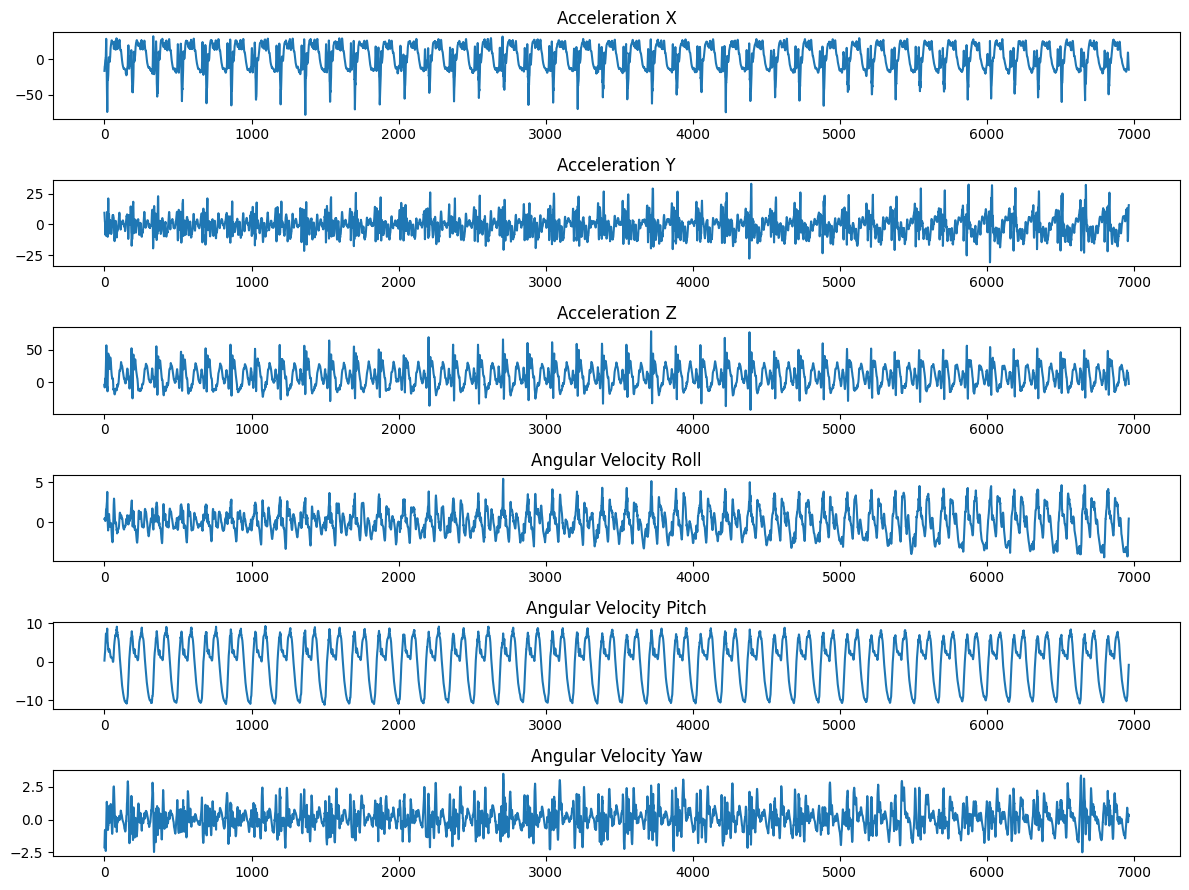

In [128]:
plt.figure(figsize=(12, 9))

plt.subplot(6, 1, 1)
plt.plot(acc_f[:, 0])
# plt.legend(['X (Forward)'])
plt.title("Acceleration X")

plt.subplot(6, 1, 2)
plt.plot(acc_f[:, 1])
# plt.legend(['Y (Lateral)'])
plt.title("Acceleration Y")

plt.subplot(6, 1, 3)
plt.plot(acc_f[:, 2])
# plt.legend(['Z (Vertical)'])
plt.title("Acceleration Z")

plt.subplot(6, 1, 4)
plt.plot(gyr_f[:, 0])
# plt.legend(['Roll'])
plt.title("Angular Velocity Roll")

plt.subplot(6, 1, 5)
plt.plot(gyr_f[:, 1])
# plt.legend(['Pitch (Main)'])
plt.title("Angular Velocity Pitch")

plt.subplot(6, 1, 6)
plt.plot(gyr_f[:, 2])
# plt.legend(['Yaw'])
plt.title("Angular Velocity Yaw")

plt.tight_layout()
plt.savefig("../picture/acc-gyr_f.png")
plt.show()

In [58]:
# IMU rotation matrix from CS_S to CS_f
print(f"R_s_pf shape: {R_s_pf.shape}")
print(f"R_pf_df shape: {R_pf_df.shape}")
print(f"R_df_f shape: {R_df_f.shape}")

R_s_f = np.zeros_like(R_pf_df)

for i in range(len(cycle_steps)):
    curr_start = int(cycle_steps[i][0]) - int(cycle_steps[0][0])
    curr_end = int(cycle_steps[i][1]) - int(cycle_steps[0][0])
    # print(f'current start: {curr_start}, end: {curr_end}')
    for t in range(curr_start, curr_end, 1):
        R_s_f[t] = R_df_f_fixed[i] @ R_pf_df[t] @ R_s_pf  # Equation (1)


# Get Euler-angles（Y-Z-X）
euler_imu = np.zeros((len(R_s_f), 3))

for t in range(len(R_s_f)):
    rot_imu = Rot.from_matrix(R_s_f[t])
    euler_imu[t] = rot_imu.as_euler('YZX', degrees=True)

R_s_pf shape: (3, 3)
R_pf_df shape: (6966, 3, 3)
R_df_f shape: (42, 3, 3)


# OMCS data

In [71]:
# relative position vectors
p1 = df_mocap_30s[['m1_x', 'm1_y', 'm1_z']].values
p2 = df_mocap_30s[['m2_x', 'm2_y', 'm2_z']].values
p3 = df_mocap_30s[['m3_x', 'm3_y', 'm3_z']].values
p4 = df_mocap_30s[['m4_x', 'm4_y', 'm4_z']].values

z_cl_gl = p2 - p1
z_cl_gl /= np.linalg.norm(z_cl_gl, axis=1, keepdims=True)

# TRIAD algorithm
y_temp = p3 - p1
x_cl_gl = np.cross(y_temp, z_cl_gl)
x_cl_gl /= np.linalg.norm(x_cl_gl, axis=1, keepdims=True)

y_cl_gl = np.cross(z_cl_gl, x_cl_gl)
y_cl_gl /= np.linalg.norm(y_cl_gl, axis=1, keepdims=True)


# Rotation matrix from OMC CS to Functional CS
R_cl_gl = np.stack([x_cl_gl, y_cl_gl, z_cl_gl], axis=2)

In [74]:
x_cl_gl[0]

array([ 0.65898892,  0.71867503, -0.22190045])

In [76]:
y_cl_gl[0]

array([-0.4254433 ,  0.11286559, -0.89791946])

In [77]:
z_cl_gl[0]

array([-0.62026737,  0.68612503,  0.38013265])

In [75]:
R_cl_gl[0]

array([[ 0.65898892, -0.4254433 , -0.62026737],
       [ 0.71867503,  0.11286559,  0.68612503],
       [-0.22190045, -0.89791946,  0.38013265]])

### Estimate rotation axis from calibration trial

In [78]:
mocap_list = ["optical_cal_pos_m1.csv", "optical_cal_pos_m2.csv", "optical_cal_pos_m3.csv", "optical_cal_pos_m4.csv"]
dfs = []
for i, filename in enumerate(mocap_list):
    df = pd.read_csv(filepath + filename, header=None)
    df.columns = [f'm{i+1}_{col}' for col in ["x", "y", "z"]]
    dfs.append(df)
df_mocap_cal_raw = pd.concat(dfs, axis=1)

# --- Upsampling (Linear Interpolation) ---
num_samples_orig = len(df_mocap_cal_raw)
time_orig = np.linspace(0, (num_samples_orig - 1) / sf_mocap, num_samples_orig)
time_new = np.linspace(0, (num_samples_orig - 1) / sf_mocap, int(num_samples_orig * sf / sf_mocap))
f_interp = interp1d(time_orig, df_mocap_cal_raw.values, axis=0, kind='linear', fill_value="extrapolate")
df_mocap_cal_upsampled = pd.DataFrame(f_interp(time_new), columns=df_mocap_cal_raw.columns)

# --- Filtering (Recursive 4th-order 20Hz Butterworth) ---
nyq = 0.5 * sf
cutoff = 20
order = 4
b, a = butter(order, cutoff / nyq, btype="low")
mocap_filt_values = filtfilt(b, a, df_mocap_cal_upsampled.values, axis=0)
df_mocap_cal = pd.DataFrame(mocap_filt_values, columns=df_mocap_cal_upsampled.columns)

In [79]:
# relative position vectors
p1 = df_mocap_cal[['m1_x', 'm1_y', 'm1_z']].values
p2 = df_mocap_cal[['m2_x', 'm2_y', 'm2_z']].values
p3 = df_mocap_cal[['m3_x', 'm3_y', 'm3_z']].values
p4 = df_mocap_cal[['m4_x', 'm4_y', 'm4_z']].values

z_cl_gl = p2 - p1
z_cl_gl /= np.linalg.norm(z_cl_gl, axis=1, keepdims=True)

# TRIAD algorithm
y_temp = p3 - p1
x_cl_gl = np.cross(y_temp, z_cl_gl)
x_cl_gl /= np.linalg.norm(x_cl_gl, axis=1, keepdims=True)

y_cl_gl = np.cross(z_cl_gl, x_cl_gl)
y_cl_gl /= np.linalg.norm(y_cl_gl, axis=1, keepdims=True)


# Rotation matrix
R_cl_gl_cal = np.stack([x_cl_gl, y_cl_gl, z_cl_gl], axis=2)

In [116]:
# Manually extract frames for each motion
frame_cal_1 = slice(1200, 4000)
frame_cal_2 = slice(4100, 7000)
frame_cal_3 = slice(7000, 10000)
frame_cal_4 = slice(11500, 14350)

# Divide each slice into 7 equal parts
frame_cal_1_divided = [slice(int(s), int(e)) for s, e in zip(np.linspace(frame_cal_1.start, frame_cal_1.stop, 8)[:-1], np.linspace(frame_cal_1.start, frame_cal_1.stop, 8)[1:])]
frame_cal_2_divided = [slice(int(s), int(e)) for s, e in zip(np.linspace(frame_cal_2.start, frame_cal_2.stop, 8)[:-1], np.linspace(frame_cal_2.start, frame_cal_2.stop, 8)[1:])]
frame_cal_3_divided = [slice(int(s), int(e)) for s, e in zip(np.linspace(frame_cal_3.start, frame_cal_3.stop, 8)[:-1], np.linspace(frame_cal_3.start, frame_cal_3.stop, 8)[1:])]
frame_cal_4_divided = [slice(int(s), int(e)) for s, e in zip(np.linspace(frame_cal_4.start, frame_cal_4.stop, 8)[:-1], np.linspace(frame_cal_4.start, frame_cal_4.stop, 8)[1:])]

<Axes: >

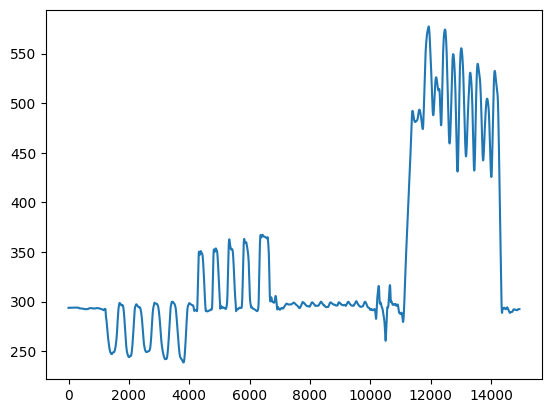

In [82]:
df_mocap_cal["m1_z"].plot()

<Axes: >

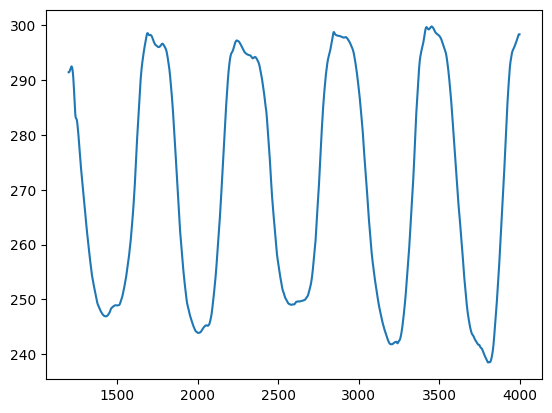

In [89]:
df_mocap_cal["m1_z"][frame_cal_1].plot()

<Axes: >

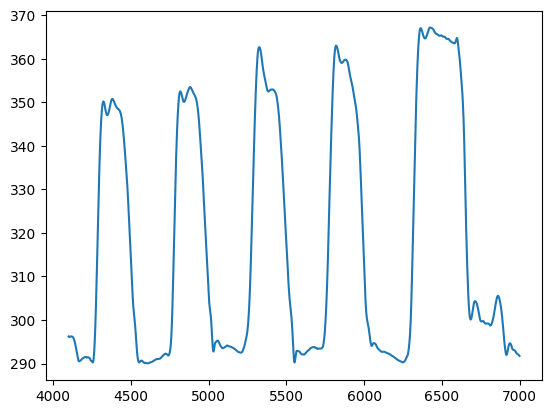

In [94]:
df_mocap_cal["m1_z"][frame_cal_2].plot()

<Axes: >

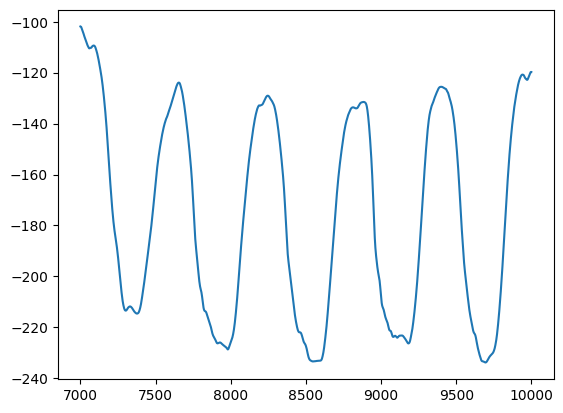

In [107]:
df_mocap_cal["m1_x"][frame_cal_3].plot()

<Axes: >

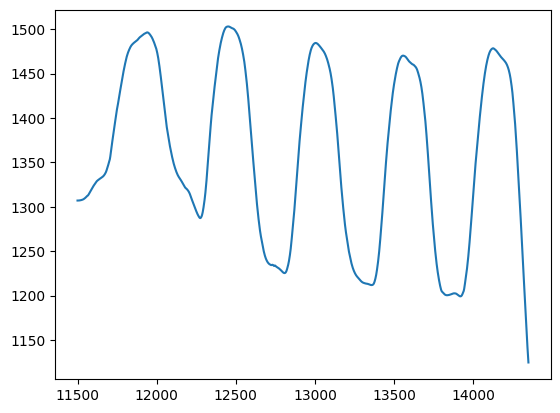

In [117]:
df_mocap_cal["m1_x"][frame_cal_4].plot()

In [118]:
# Calculate rotation matrices between the start points of each 7-segment interval
rotation_matrices = []
all_axes = []

for divided_frames in [frame_cal_1_divided, frame_cal_2_divided, frame_cal_3_divided, frame_cal_4_divided]:
    for i in range(len(divided_frames) - 1):
        # Start point of interval i
        t_j = divided_frames[i].start
        # Start point of next interval
        t_j_plus_1 = divided_frames[i + 1].start

        # Rotation matrix at each time point
        R_j = R_cl_gl_cal[t_j]
        R_j_plus_1 = R_cl_gl_cal[t_j_plus_1]

        # Relative rotation matrix from t_j to t_j_plus_1 (Equation 9a)
        R_delta = R_j.T @ R_j_plus_1

        rotation_matrices.append(R_delta)

        # Extract rotation vector (vector part of quaternion)
        rot = Rot.from_matrix(R_delta)
        q = rot.as_quat() # [x, y, z, w]
        v_rot = q[:3] # Vector part [x, y, z]

        # Orientation correction for extension
        # Reverse if pointing opposite to the main rotation direction
        if len(all_axes) > 0:
            if np.dot(v_rot, all_axes[0]) < 0:
                v_rot = -v_rot

        all_axes.append(v_rot)

rotation_matrices = np.array(rotation_matrices)
# Average all rotation axes and normalize (corresponds to final equation)
y_f_gl = np.mean(all_axes, axis=0)
y_f_gl /= np.linalg.norm(y_f_gl)

# Construct orthogonal coordinate system using TRIAD algorithm
z_temp = np.array([0, 0, 1])  # Temporary z-axis
x_f_gl = np.cross(y_f_gl, z_temp)
x_f_gl /= np.linalg.norm(x_f_gl)

z_f_gl = np.cross(x_f_gl, y_f_gl)
z_f_gl /= np.linalg.norm(z_f_gl)

# Equation 9f: Rotation matrix from Y_f to Y_gl
R_f_gl = np.stack([x_f_gl, y_f_gl, z_f_gl], axis=1)

In [123]:
# Equation (10)
# R_cl_f(t) = R_f_gl^(-1) @ R_cl_gl(t)
R_cl_f_gait = np.zeros_like(R_cl_gl)  # shape: (n_frames, 3, 3)

for t in range(len(R_cl_gl)):
    R_cl_f_gait[t] = R_f_gl.T @ R_cl_gl[t]

print(f"R_cl_f_gait shape: {R_cl_f_gait.shape}")

# Get Euler angles
euler_mocap = np.zeros((len(R_cl_f_gait), 3))

for t in range(len(R_cl_f_gait)):
    rot_mocap = Rot.from_matrix(R_cl_f_gait[t])
    euler_mocap[t] = rot_mocap.as_euler('YZX', degrees=True)
    if euler_mocap[t, 2] > 100:
        euler_mocap[t, 2] -= 360

R_cl_f_gait shape: (7200, 3, 3)


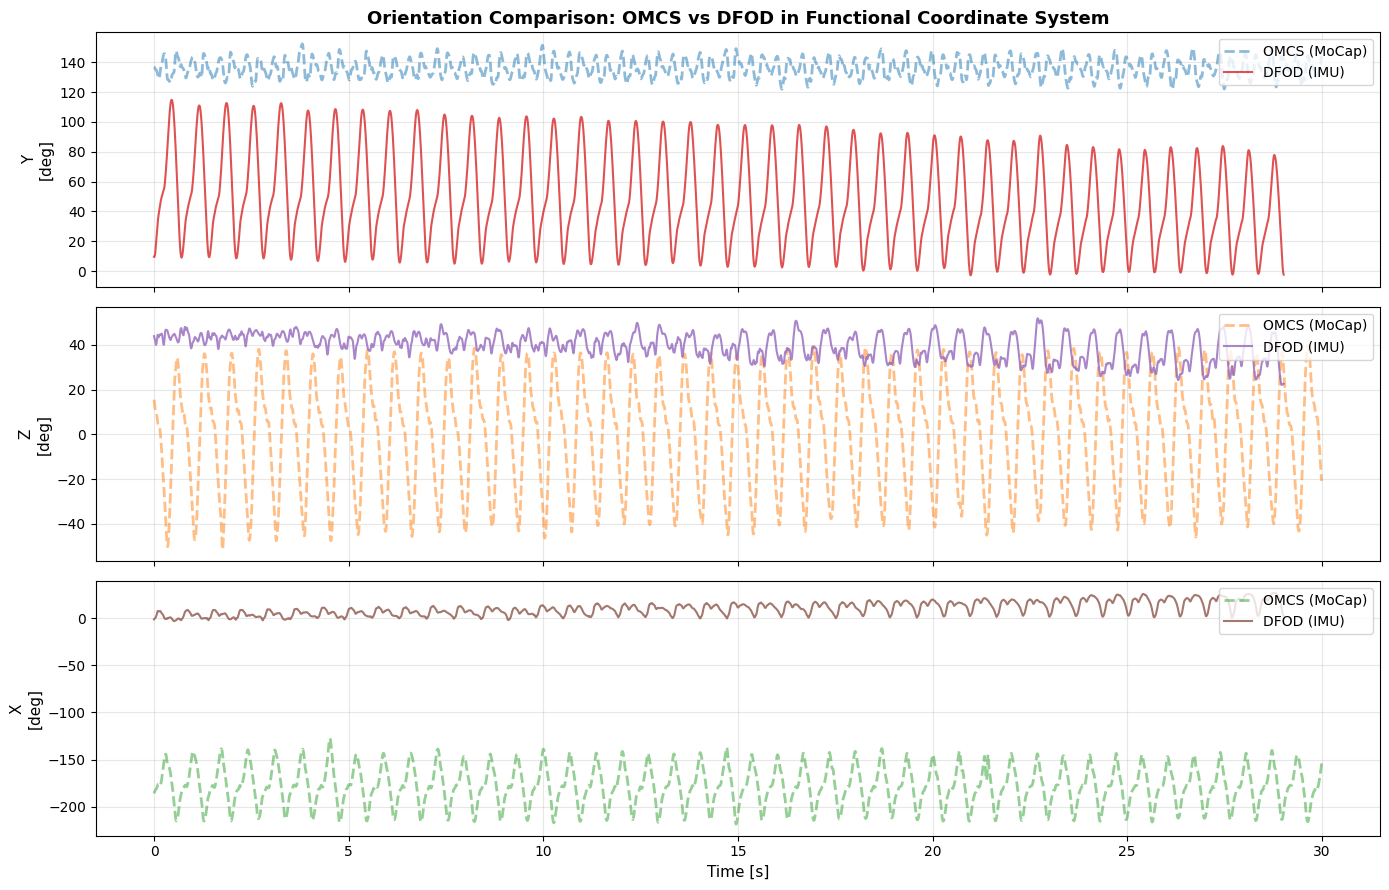

In [125]:
time_mocap = np.arange(len(euler_mocap)) / sf
time_imu = np.arange(len(euler_imu)) / sf

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axis_names = ['Y', 'Z', 'X']
colors_mocap = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_imu = ['#d62728', '#9467bd', '#8c564b']

for i, (ax, name) in enumerate(zip(axes, axis_names)):
    ax.plot(time_mocap, euler_mocap[:, i], label='OMCS (MoCap)', 
            linewidth=2, color=colors_mocap[i], linestyle='--', alpha=0.5)
    ax.plot(time_imu, euler_imu[:, i], label='DFOD (IMU)', 
            linewidth=1.5, alpha=0.8, color=colors_imu[i], zorder=5)
    ax.set_ylabel(f'{name}\n[deg]', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]', fontsize=11)
axes[0].set_title('Orientation Comparison: OMCS vs DFOD in Functional Coordinate System', 
                  fontsize=13, fontweight='bold')
# plt.xlim([0, 20])
plt.tight_layout()
plt.show()